In [1]:
import pandas as pd
import numpy as np

ModuleNotFoundError: No module named 'pandas'

In [2]:
import pandas as pd
import numpy as np

In [3]:
import os
print(os.listdir())

['.venv', 'cleaned_dataset.xlsx', 'Dataset.xlsx', 'data_cleaning.ipynb', 'data_dictionary.xlsx', 'README.md']


In [4]:
df = pd.read_excel("Dataset.xlsx")

df.head()

ValueError: Excel file format cannot be determined, you must specify an engine manually.

In [5]:
import os

print(os.path.getsize("Dataset.xlsx"))

0


In [6]:
with open("Dataset.xlsx", "rb") as f:
    print(f.read(20))

b''


In [7]:
df = pd.read_excel("Dataset.xlsx", engine="openpyxl")
df.head()

BadZipFile: File is not a zip file

In [8]:
import pandas as pd

df = pd.read_excel("Dataset.xlsx")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Dataset.xlsx'

In [9]:
import os
print(os.listdir())

['.venv', 'Dataset.xlsx.xlsx', 'data_cleaning.ipynb']


In [10]:
df = pd.read_excel("Dataset.xlsx")

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Dataset.xlsx'

In [11]:
df = pd.read_excel("ApexPlanet_DataAnalytics_Dataset.xlsx")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'ApexPlanet_DataAnalytics_Dataset.xlsx'

In [12]:
import os
print(os.listdir())

['.venv', 'Dataset.xlsx.xlsx', 'data_cleaning.ipynb']


In [13]:
import os
print(os.listdir())


['.venv', 'Dataset.xlsx', 'data_cleaning.ipynb']


In [14]:
df = pd.read_excel("Dataset.xlsx")

df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       1000 non-null   str    
 1   Order_Date     1000 non-null   str    
 2   Customer_ID    1000 non-null   str    
 3   Customer_Name  1000 non-null   str    
 4   Age            980 non-null    float64
 5   Gender         1000 non-null   str    
 6   City           987 non-null    str    
 7   Product        1000 non-null   str    
 8   Category       1000 non-null   str    
 9   Quantity       1000 non-null   int64  
 10  Unit_Price     1000 non-null   float64
 11  Total_Sales    1000 non-null   float64
dtypes: float64(3), int64(1), str(8)
memory usage: 93.9 KB


In [16]:
df.shape

(1000, 12)

In [17]:
df.columns.tolist()

['Order_ID',
 'Order_Date',
 'Customer_ID',
 'Customer_Name',
 'Age',
 'Gender',
 'City',
 'Product',
 'Category',
 'Quantity',
 'Unit_Price',
 'Total_Sales']

In [18]:
df.isnull().sum()

Order_ID          0
Order_Date        0
Customer_ID       0
Customer_Name     0
Age              20
Gender            0
City             13
Product           0
Category          0
Quantity          0
Unit_Price        0
Total_Sales       0
dtype: int64

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.describe()

,Age,Quantity,Unit_Price,Total_Sales
count,980.000000,1000.000000,1000.000000,1000.000000
mean,41.360204,5.435000,25486.783410,139399.439650
std,13.822597,2.838632,14179.402361,114100.051546
min,18.000000,1.000000,145.780000,437.340000
25%,30.000000,3.000000,13895.722500,47066.632500
50%,41.000000,5.000000,25398.740000,108594.025000
75%,54.000000,8.000000,37512.382500,203722.882500
max,65.000000,10.000000,49997.530000,493677.500000


In [21]:
data_dictionary = pd.DataFrame({
    'Column_Name': df.columns,
    'Data_Type': df.dtypes.astype(str).values
})

data_dictionary

,Column_Name,Data_Type
0,Order_ID,str
1,Order_Date,str
2,Customer_ID,str
3,Customer_Name,str
4,Age,float64
5,Gender,str
6,City,str
7,Product,str
8,Category,str
9,Quantity,int64


In [22]:
data_dictionary.to_excel("data_dictionary.xlsx", index=False)

In [23]:
df = df.drop_duplicates()

In [24]:
for col in df.select_dtypes(include=['int64','float64']).columns:
    df[col] = df[col].fillna(df[col].median())

In [25]:
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

C:\Users\HARSH JAIN\AppData\Local\Temp\ipykernel_4844\3486712827.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


In [26]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

In [28]:
df.to_excel("cleaned_dataset.xlsx", index=False)


In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       1000 non-null   str           
 1   Order_Date     1000 non-null   datetime64[us]
 2   Customer_ID    1000 non-null   str           
 3   Customer_Name  1000 non-null   str           
 4   Age            1000 non-null   float64       
 5   Gender         1000 non-null   str           
 6   City           1000 non-null   str           
 7   Product        1000 non-null   str           
 8   Category       1000 non-null   str           
 9   Quantity       1000 non-null   int64         
 10  Unit_Price     1000 non-null   float64       
 11  Total_Sales    1000 non-null   float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(7)
memory usage: 93.9 KB


In [30]:
df.isnull().sum()

Order_ID         0
Order_Date       0
Customer_ID      0
Customer_Name    0
Age              0
Gender           0
City             0
Product          0
Category         0
Quantity         0
Unit_Price       0
Total_Sales      0
dtype: int64

In [31]:
df.duplicated().sum()

np.int64(0)

In [32]:
df.columns.tolist()

['Order_ID',
 'Order_Date',
 'Customer_ID',
 'Customer_Name',
 'Age',
 'Gender',
 'City',
 'Product',
 'Category',
 'Quantity',
 'Unit_Price',
 'Total_Sales']

In [33]:
data_dictionary = pd.DataFrame({
    'Column_Name': df.columns,
    'Data_Type': df.dtypes.astype(str).values
})

data_dictionary

,Column_Name,Data_Type
0,Order_ID,str
1,Order_Date,datetime64[us]
2,Customer_ID,str
3,Customer_Name,str
4,Age,float64
5,Gender,str
6,City,str
7,Product,str
8,Category,str
9,Quantity,int64


In [34]:
data_dictionary.to_excel("data_dictionary.xlsx", index=False)

In [35]:
df.to_excel("cleaned_dataset.xlsx", index=False)

In [36]:
df.describe()

,Order_Date,Age,Quantity,Unit_Price,Total_Sales
count,1000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2025-07-03 11:19:40.800000,41.353000,5.435000,25486.783410,139399.439650
min,2025-01-01 00:00:00,18.000000,1.000000,145.780000,437.340000
25%,2025-03-30 18:00:00,30.000000,3.000000,13895.722500,47066.632500
50%,2025-07-01 00:00:00,41.000000,5.000000,25398.740000,108594.025000
75%,2025-10-07 06:00:00,53.000000,8.000000,37512.382500,203722.882500
max,2026-01-01 00:00:00,65.000000,10.000000,49997.530000,493677.500000
std,NaN,13.683626,2.838632,14179.402361,114100.051546


In [37]:
df['Category'].value_counts()

Category
Electronics    354
Education      178
Furniture      159
Fashion        156
Grocery        153
Name: count, dtype: int64

In [38]:
df['City'].value_counts()

City
Patna        148
Kolkata      133
Mumbai       131
Hyderabad    125
Delhi        125
Bengaluru    122
Gaya         117
Pune          99
Name: count, dtype: int64

In [39]:
df['Gender'].value_counts()

Gender
Male      511
Female    489
Name: count, dtype: int64

In [40]:
import matplotlib.pyplot as plt

df['Category'].value_counts().plot(kind='bar')
plt.title("Products by Category")
plt.show()

ModuleNotFoundError: No module named 'matplotlib'

In [41]:
df['City'].value_counts().plot(kind='bar')
plt.title("Orders by City")
plt.show()

ImportError: matplotlib is required for plotting when the default backend "matplotlib" is selected.

In [42]:
df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Customer Gender Distribution")
plt.show()

ImportError: matplotlib is required for plotting when the default backend "matplotlib" is selected.

In [43]:
import sys
print(sys.executable)

c:\Users\HARSH JAIN\Downloads\DataAnalytics_Task1\.venv\Scripts\python.exe


In [44]:
.\.venv\Scripts\python.exe -m pip install matplotlib


SyntaxError: invalid syntax (2115297157.py, line 1)

In [45]:
.\.venv\Scripts\python.exe -m pip install matplotlib

SyntaxError: invalid syntax (3435153369.py, line 1)

In [46]:
.\.venv\Scripts\python.exe -m pip install matplotlib

SyntaxError: invalid syntax (3435153369.py, line 1)

In [47]:
!.\.venv\Scripts\python.exe -m pip install matplotlib

  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ------------ --------------------------- 2.6/8.2 MB 13.7 MB/s eta 0:00:01
   ------------------------------- -------- 6.6/8.2 MB 16.0 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 14.2 MB/s eta 0:00:00
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 23.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ----------------- ---------------------- 3.1/7.1 MB 15.4 MB/s eta 0:00:01
   ---------------------------------- ----- 6.0/7.1 MB 14.1 MB/s eta 0:00:01
   ---------------------------------------- 7.1/7.1 MB 13.2 MB/s eta 0:00:0


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [48]:
import matplotlib.pyplot as plt

print("Success")

Success


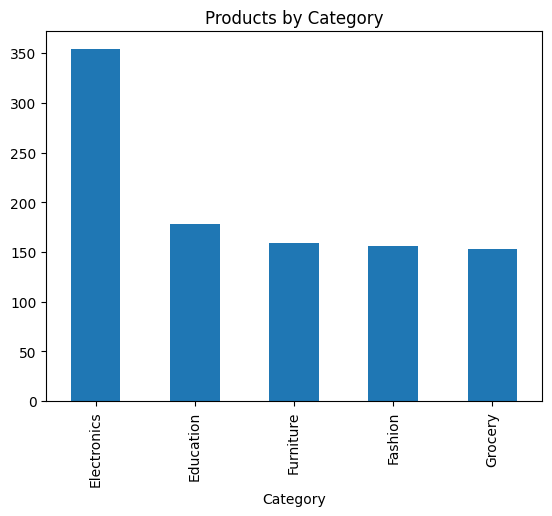

In [49]:
df['Category'].value_counts().plot(kind='bar')
plt.title("Products by Category")
plt.show()

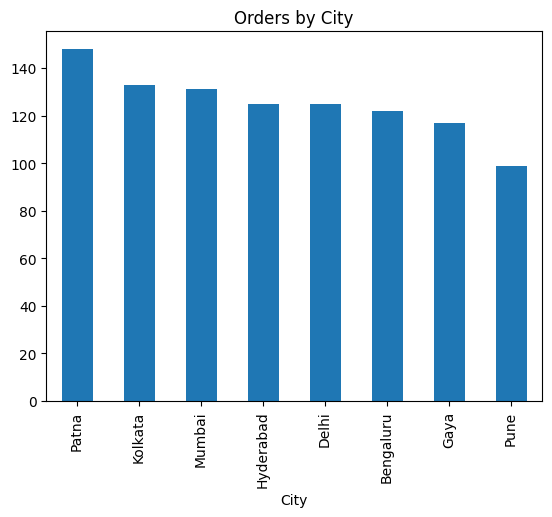

In [50]:
df['City'].value_counts().plot(kind='bar')
plt.title("Orders by City")
plt.show()

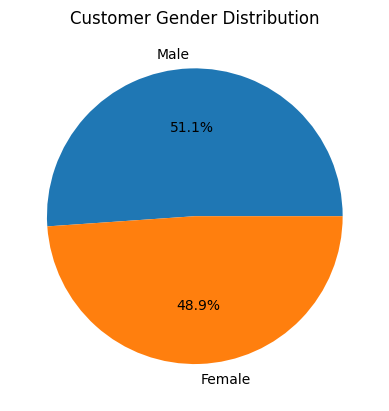

In [51]:
df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Customer Gender Distribution")
plt.show()

In [52]:
import matplotlib.pyplot as plt

print("Success")

Success


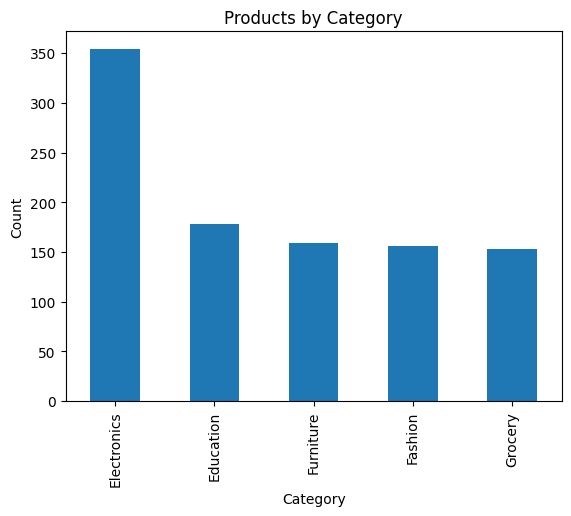

In [53]:
df['Category'].value_counts().plot(kind='bar')
plt.title("Products by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

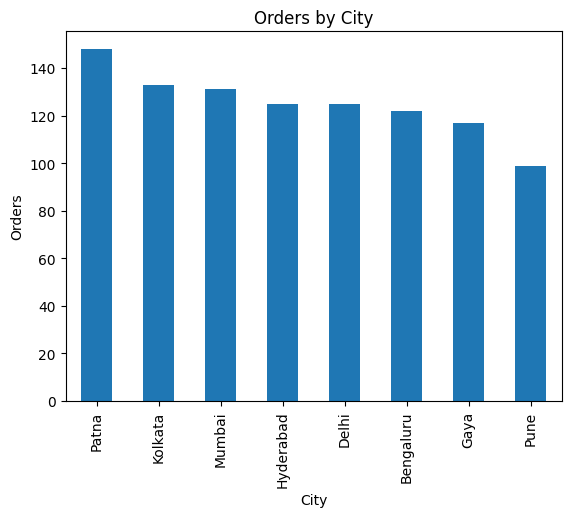

In [54]:
df['City'].value_counts().plot(kind='bar')
plt.title("Orders by City")
plt.xlabel("City")
plt.ylabel("Orders")
plt.show()

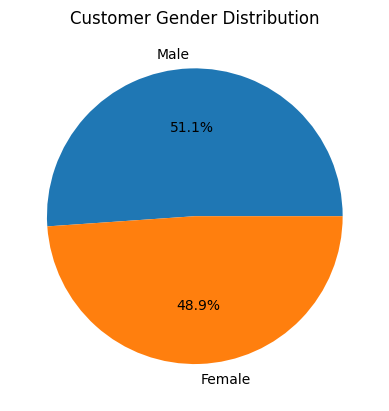

In [55]:
df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Customer Gender Distribution")
plt.ylabel("")
plt.show()